# Система поиска товаров на основе дообученной CLIP-модели

Дообучаем CLIP на датасете товаров из магазинов одежды и реализуем систему поиска изображений по текстовым запросам.

## Содержание
- [1. EDA](#1)
- [2. Подготовка данных](#2)
  - [2.1 Очистка](#2-1)
  - [2.2 Train/test split](#2-2)
  - [2.3 Dataset класс](#2-3)
- [3. Базовая модель](#3)
- [4. Дообучение](#4)
- [5. Система поиска](#5)

In [1]:
import random
from pathlib import Path

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

RANDOM_STATE = 42

/Users/anna_gladun/Projects/analytics-hub/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<a id="1"></a>
## 1. EDA

Загружаю датасет с Kaggle и смотрю на данные: визуализирую пары картинка + описание, анализирую качество текстов, разрешение изображений и дубликаты.

In [2]:
cached_path = Path('~/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset').expanduser()

if cached_path.exists():
    dataset_path = sorted(cached_path.glob('versions/*'))[-1]
    print(f'Датасет уже скачан: {dataset_path}')
else:
    dataset_path = Path(kagglehub.dataset_download('nirmalsankalana/fashion-product-text-images-dataset'))
    print(f'Скачан: {dataset_path}')

Датасет уже скачан: /Users/anna_gladun/.cache/kagglehub/datasets/nirmalsankalana/fashion-product-text-images-dataset/versions/1


In [3]:
# загружаем таблицу и определяем путь к изображениям
df = pd.read_csv(dataset_path / 'data.csv')
images_dir = dataset_path / 'data'

print(f'Записей: {len(df):,}')
df.head(3)

Записей: 44,441


,image,description,display name,category
0,3238.jpg,"Round toed, black sports shoes with red accent...",Puma Men Black 65CC Lo Ducati Sports Shoes,Sports Shoes
1,43044.jpg,Style Note Built with the breathability and ze...,Nike Men Charcoal Grey Shorts,Shorts
2,54018.jpg,Teal handbag that has stitch detailing with a...,Kiara Women Teal Handbag,Handbags


In [4]:
print('Присутствуют изображения без описания и display name: ')
print()

df.info()

Присутствуют изображения без описания и display name: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44441 entries, 0 to 44440
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image         44441 non-null  object
 1   description   44160 non-null  object
 2   display name  44434 non-null  object
 3   category      44441 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


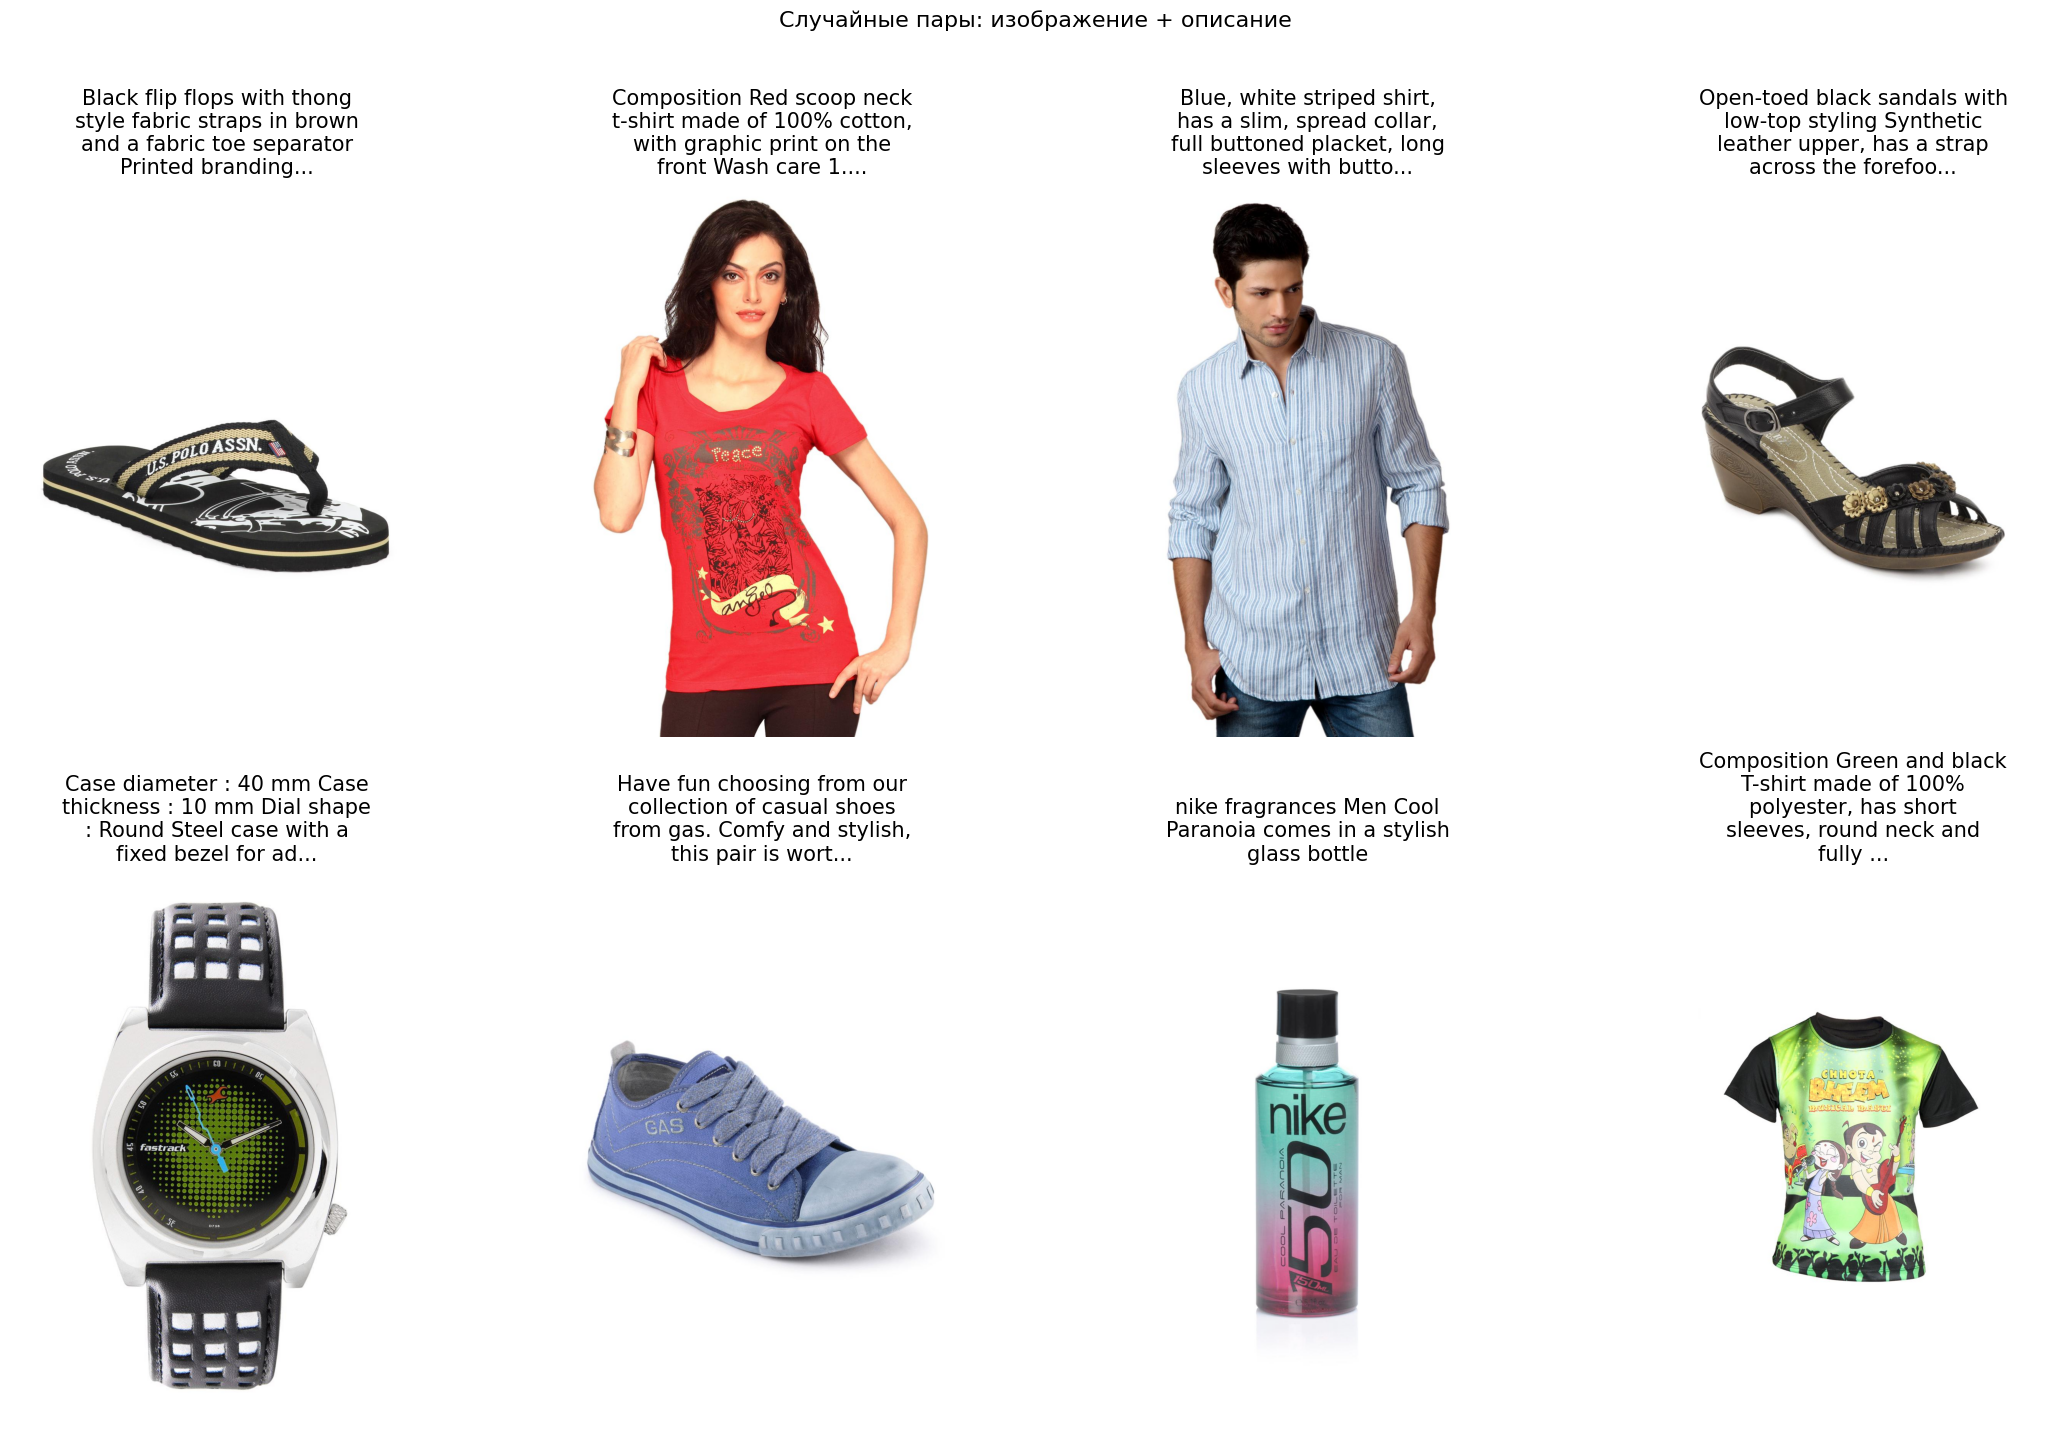

In [5]:
import textwrap

sample_df = df[['image', 'description']].dropna().sample(8, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 4, figsize=(22, 14))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    img_path = images_dir / row['image']
    if img_path.exists():
        ax.imshow(Image.open(img_path))
    desc = row['description']
    truncated = desc[:100] + '...' if len(desc) > 100 else desc
    ax.set_title(textwrap.fill(truncated, width=28), fontsize=15, pad=8)
    ax.axis('off')

plt.suptitle('Случайные пары: изображение + описание', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Разрешение изображений

Проверим на выборке из 1000 изображений - если все одного размера, предобработка будет простой и единообразной.

In [6]:
sample_files = df['image'].dropna().sample(1000, random_state=RANDOM_STATE).tolist()
resolutions = []

for fname in sample_files:
    img_path = images_dir / fname
    if img_path.exists():
        with Image.open(img_path) as img:
            resolutions.append(img.size)

pd.Series(resolutions).value_counts().to_frame(name='count')

,count
"(1080, 1440)",1000


### Анализ текстовых описаний

In [7]:
df['descr_len'] = df['description'].str.len()
df['descr_cnt_words'] = df['description'].str.split().str.len()

In [8]:
print('В описаниях присутствуют сильные выбросы: ')
df[['descr_cnt_words', 'descr_len']].describe(
    percentiles=[.05, .1, .25, .5, .75, .9, .95, .99]
).round(1)

В описаниях присутствуют сильные выбросы: 


,descr_cnt_words,descr_len
count,44160.0,44160.0
mean,93.8,555.6
std,56.9,381.6
min,0.0,1.0
5%,12.0,73.0
10%,18.0,111.0
25%,42.0,254.0
50%,102.0,593.0
75%,130.0,761.0
90%,156.0,921.0


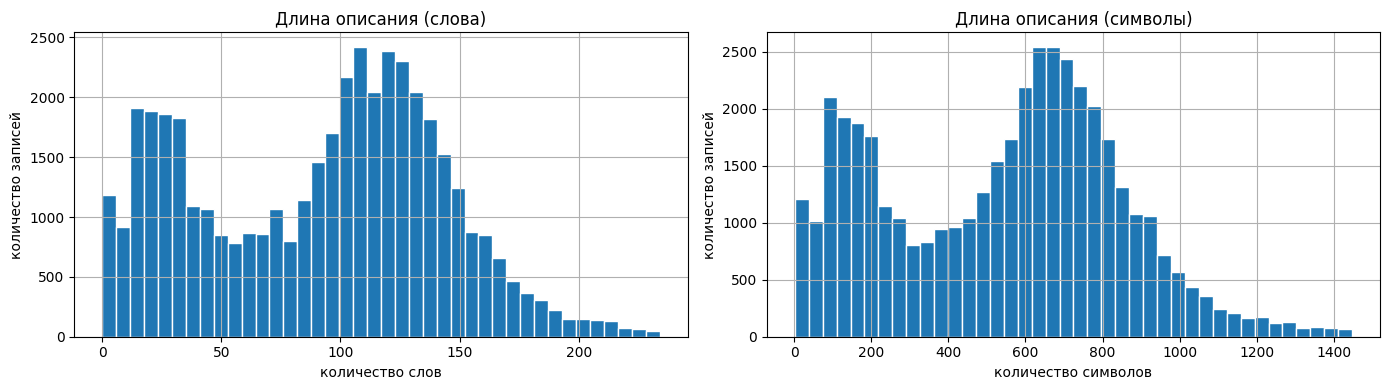

In [9]:
p99_words = df['descr_cnt_words'].quantile(0.99)
p99_len = df['descr_len'].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df.loc[df['descr_cnt_words'] <= p99_words, 'descr_cnt_words'].dropna(), bins=40, edgecolor='white')
axes[0].set_title('Длина описания (слова)')
axes[0].set_xlabel('количество слов')
axes[0].set_ylabel('количество записей')
axes[0].grid(True)

axes[1].hist(df.loc[df['descr_len'] <= p99_len, 'descr_len'].dropna(), bins=40, edgecolor='white')
axes[1].set_title('Длина описания (символы)')
axes[1].set_xlabel('количество символов')
axes[1].set_ylabel('количество записей')
axes[1].grid(True)

plt.tight_layout()
plt.show()

Распределение двугорбое - судя по всему, в датасете два типа карточек. Посмотрим на примеры из каждого пика, чтобы понять чем они различаются по содержанию.

In [10]:
# смотрим примеры из первого пика (10–40 слов) и второго (90–140 слов)
short = df[df['descr_cnt_words'].between(10, 40)]['description'].dropna().sample(5, random_state=RANDOM_STATE)
long = df[df['descr_cnt_words'].between(90, 140)]['description'].dropna().sample(5, random_state=RANDOM_STATE)

print('=== Короткие (10–40 слов) ===')
for i, text in enumerate(short, 1):
    print(f'{i}. {text}\n')

print('=== Длинные (90–140 слов) ===')
for i, text in enumerate(long, 1):
    print(f'{i}. {text}\n')

=== Короткие (10–40 слов) ===
1. revv is an imported stainless steel collection that suits the trendsetting youth of today - cool college goers, young executives and those who like to remain ahead of the pack.

2. Blue and white striped shirt made of 100% cotton, has a spread collar, long sleeves with single button cuffs, full buttoned placket, brand badge above the left hem and a curved hem 

3. C are  Machine wash cold with like colours Do not bleach Tumble dry on low Do not iron or dry clean

4. Grey and blue striped polo T-shirt, has a polo collar, short button placket, short sleeves

5. Blue flip flops Thong style upper with branding and simple pattern design Textured and printed footbed Rubber outsole with grooves

=== Длинные (90–140 слов) ===
1. Composition Black round neck t-shirt made of 100% cotton, with chest print  Fitting Comfort  Wash care 1. Light machine wash 2. Do not bleach 3. Warm iron on reverse 4. Do not dry clean 5. Dry flat/reverse 6. Do not scrub Mad at your bo

Короткие описания неоднородны по качеству. Часть из них отличные: конкретные визуальные характеристики товара (цвет, материал, крой, детали). Но среди них же встречается чистый мусор - только инструкция по уходу без единого слова о внешнем виде (пример 3).

Длинные описания устроены по единому шаблону: сначала идет визуальная часть (Composition + цвет + тип + детали), потом уход, потом маркетинговый текст, в конце параметры модели. Структура предсказуемая, и это хорошо - визуальный контент попадает в начало и, скорее всего, уместится в 77 токенов CLIP. Проблема только в карточках с префиксом Style Note (пример 4): там сначала идет рекламный текст, а товарные детали спрятаны глубже.

Помимо двух основных пиков, есть небольшой хвост слева - очень короткие описания. Интересно что там: реальные краткие характеристики или мусор.

In [11]:
print('=== меньше 4 слов ===')
display(df[df['descr_cnt_words'] < 4]['description'].dropna().value_counts().head(10).to_frame())

print('=== 4–6 слов ===')
display(df[df['descr_cnt_words'].between(4, 6)]['description'].dropna().value_counts().head(10).to_frame())

print('=== 6–10 слов ===')
display(df[df['descr_cnt_words'].between(6, 10)]['description'].dropna().value_counts().head(10).to_frame())

=== меньше 4 слов ===


,count
description,
-,934
Style Note,115
Style Description,16
Style Note Create,5
Style Note Girls,5
Syle Note,4
Flat sandals,3
Style Note Check,3
Style Note,3


=== 4–6 слов ===


,count
description,
Style Note Girls love <,12
Warranty : 2 Years,11
Green striped polo tshirt.,2
Purple printed georgette sari,2
Multi-coloured printed georgette sari,2
Longlasting blush Soft applicator Transparent cover,2
Red aerosol spray can,2
Pink striped polo tshirt.,2
Style Note Girls love <,2


=== 6–10 слов ===


,count
description,
High gloss finish nail polish Smooth brush applicator,43
Long lasting and fade resistant eye shadow,14
Enriched with emollients to moisturize and condition your lips,6
Lakme True Wear nail colour Has an easy applicator brush,6
"Style Note Created for the woman of sophistication, this",5
Satiny smooth application and a shimmery finish Well-designed casing,5
Semi-sheer shine with glitter particles Glossy and light,5
"Pack of two, (Buy 1 get 1 free)",4
cavallini Deodorant for women comes in a aerosol spray canister,4


Очевидный мусор - 934 прочерка, сотни вариаций Style Note, одиночные слова. Убираем всё это по маскам. Ключевой принцип: фильтруем по началу строки, потому что CLIP берёт именно начало текста - если там стоит шаблонный маркер, визуальная часть до модели просто не доберётся.

Заодно посмотрим на распределение первых двух слов по всему датасету - это хороший способ найти системные паттерны, которые не очевидны при ручном просмотре.

In [12]:
first_two = df['description'].dropna().str.strip().str.split().str[:2].str.join(' ')
display(first_two.value_counts().head(30).to_frame())

,count
description,
Style Note,7841
Composition Black,1655
Composition White,1372
Case style:,1209
Composition Blue,1165
-,934
Composition Grey,730
Composition Red,620
Composition Navy,578


In [ ]:
for prefix in ['Style Note', 'Wash care', 'Case style:', 'Lens colour:', 'Pack of', 'Designed for', 'Warranty']:
    subset = df[df['description'].str.strip().str.startswith(prefix, na=False)]['description']
    sample = subset.drop_duplicates().sample(min(2, subset.nunique()), random_state=RANDOM_STATE)
    print(f'=== {prefix} ({len(subset)} записей) ===')
    for text in sample:
        print(f'  {text[:200]}')
    print()

Несколько интересных находок. `Wash care` (70) - чисто инструкции по уходу, никакого визуального контента. `Case style:` (1198) - описания часов в формате поле-значение, не одежда вообще. `Lens colour:` (277) - аналогично, технические характеристики очков. `Warranty` (5) - просто текст гарантии. Всё это убираем.

`Style Note` (7225) отдельный случай: это маркетинговые тексты, не технический шаблон, но визуальных деталей (цвет, крой, материал) там практически нет. Убираем.

`Pack of` и `Designed for` оставляем: примеры показали, что за этими началами идёт нормальное визуальное описание товара.

In [ ]:
noise_keywords = [
    'Style Note', 'Syle Note', 'Style Description',
    'Wash care', 'Case style:', 'Lens colour:', 'Warranty', 'Note'
]

mask_null = df['description'].isna()
mask_empty = df['description'].str.strip().isin(['-', ''])
mask_one_word = df['descr_cnt_words'] <= 1
mask_keywords = df['description'].str.strip().str.startswith(tuple(noise_keywords), na=False)

mask_drop = mask_null | mask_empty | mask_one_word | mask_keywords

In [14]:
# смотрим короткие описания после применения маски
display(df[~mask_drop][df[~mask_drop]['descr_cnt_words'] <= 6]['description'].value_counts().head(20).to_frame())

,count
description,
Flat sandals,3
Pink striped polo tshirt.,2
Green striped polo tshirt.,2
Red aerosol spray can,2
Longlasting blush Soft applicator Transparent cover,2
Purple printed georgette sari,2
Multi-coloured printed georgette sari,2
Tie care only dry clean,2
Green and black aerosol spray can,1


После масок в коротких описаниях всё ещё встречаются артефакты вроде `Tie care only dry clean` или `test desc1`. Это разрозненный шум без общего паттерна - чистить точечно не имеет смысла, слишком много вариантов. На фоне 30+ тысяч записей это единицы, вряд ли заметно повлияют на качество.

### Дубликаты

Смотрим на три сценария: точное совпадение пары `(image, description)`, один файл с разными описаниями, и дубли изображений по хэшу.

In [15]:
df_clean = df[~mask_drop]

print(f'Дубли по (image, description): {df_clean.duplicated(subset=["image", "description"]).sum()}')
print(f'Дубли по image (разные описания): {df_clean.duplicated(subset=["image"], keep=False).sum() - df_clean.duplicated(subset=["image", "description"]).sum()}')
print(f'Дубли по description (разные картинки): {df_clean.duplicated(subset=["description"], keep=False).sum()}')

Дубли по (image, description): 0
Дубли по image (разные описания): 0
Дубли по description (разные картинки): 5158


Точных дублей нет. Но одна картинка может лежать под разными именами - это не поймать через сравнение строк. Проверим по MD5-хэшу файлов.

In [16]:
import hashlib

def file_hash(path):
    return hashlib.md5(open(path, 'rb').read()).hexdigest()

hashes = {}
for fname in tqdm(df_clean['image'].dropna().unique(), desc='Хэшируем'):
    img_path = images_dir / fname
    if img_path.exists():
        hashes[fname] = file_hash(img_path)

hash_series = pd.Series(hashes)
dup_hashes = hash_series[hash_series.duplicated(keep=False)]
print(f'Файлов с одинаковым хэшем: {len(dup_hashes)}')

if len(dup_hashes) > 0:
    display(dup_hashes.reset_index().rename(columns={'index': 'filename', 0: 'hash'}).sort_values('hash').head(10))

Хэшируем:   0%|          | 0/32938 [00:00<?, ?it/s]

Хэшируем: 100%|██████████| 32938/32938 [00:12<00:00, 2698.26it/s]

Файлов с одинаковым хэшем: 894


,filename,hash
799,34064.jpg,002cc64e436ae215046405929f4c972f
337,31128.jpg,002cc64e436ae215046405929f4c972f
571,28174.jpg,007c4ee54877702eb423e93ba546010b
767,28182.jpg,007c4ee54877702eb423e93ba546010b
223,4923.jpg,02cd77390c2bc3c51d02c65714320ba2
533,4924.jpg,02cd77390c2bc3c51d02c65714320ba2
511,4899.jpg,03ae9aad52e58d1eee377ca83815433b
549,4898.jpg,03ae9aad52e58d1eee377ca83815433b
492,41236.jpg,03d4622bd56f1bae4717e52f4a0cc156
887,47151.jpg,03d4622bd56f1bae4717e52f4a0cc156


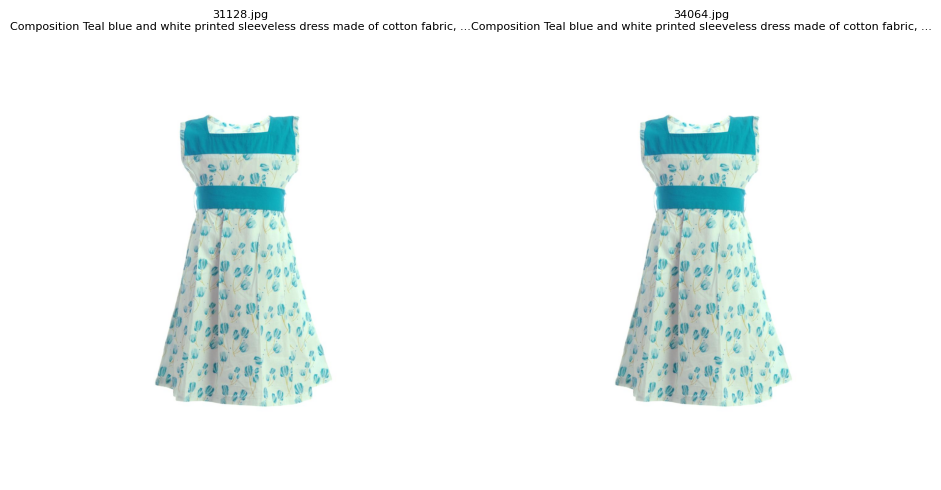

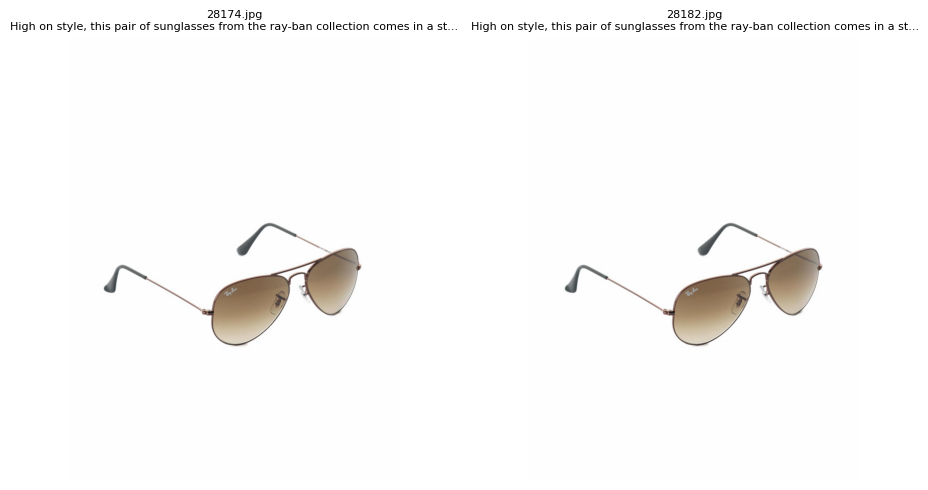

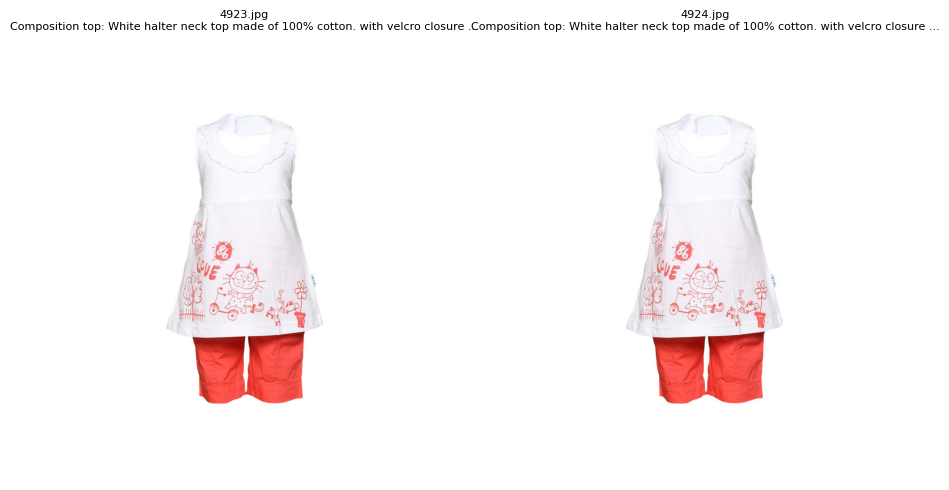

In [17]:
# берём несколько групп с одинаковым хэшем и смотрим на картинки и описания
hash_to_files = dup_hashes.reset_index().groupby(0)['index'].apply(list)
example_groups = hash_to_files.head(3)

for img_hash, files in example_groups.items():
    rows = df_clean[df_clean['image'].isin(files)][['image', 'description']]
    
    fig, axes = plt.subplots(1, len(files), figsize=(5 * len(files), 5))
    if len(files) == 1:
        axes = [axes]
    
    for ax, fname in zip(axes, files):
        img_path = images_dir / fname
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        desc = rows[rows['image'] == fname]['description'].values
        desc_text = desc[0][:80] + '...' if len(desc) > 0 and len(desc[0]) > 80 else (desc[0] if len(desc) > 0 else '')
        ax.set_title(f'{fname}\n{desc_text}', fontsize=8)
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()

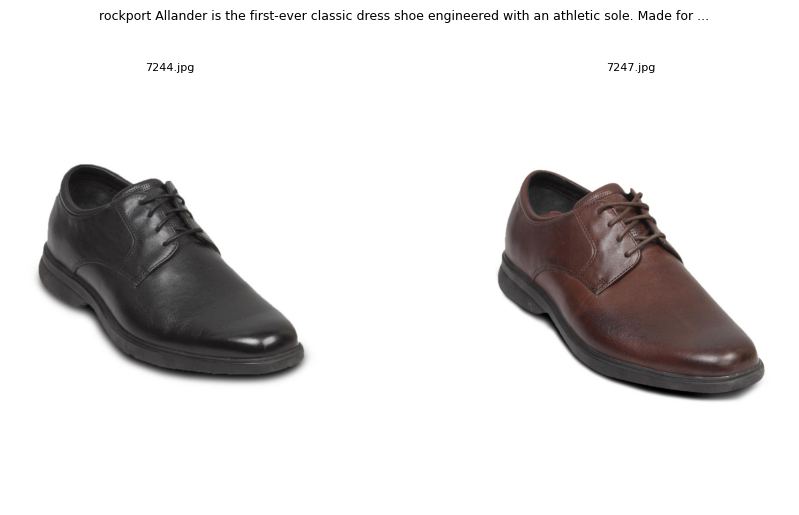

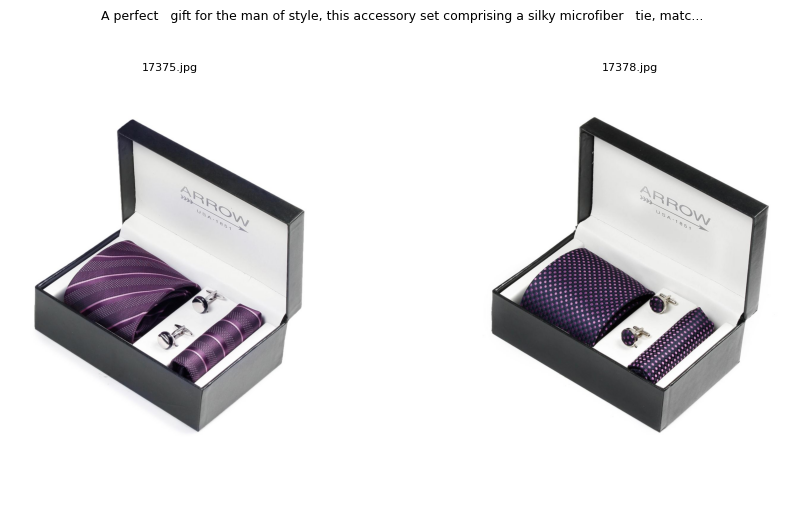

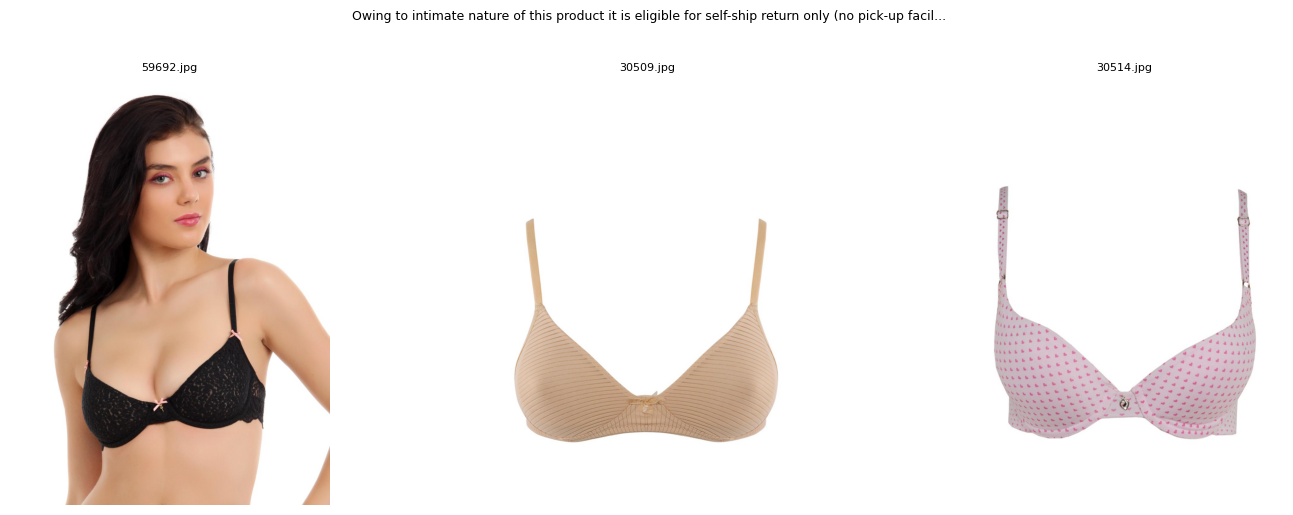

In [18]:
# смотрим примеры: одинаковое описание, разные картинки
dup_desc_groups = df_clean[df_clean.duplicated(subset=['description'], keep=False)].groupby('description')['image'].apply(list)

for desc, files in list(dup_desc_groups.items())[:3]:
    files = files[:4]  # не больше 4 для читаемости
    fig, axes = plt.subplots(1, len(files), figsize=(5 * len(files), 5))
    if len(files) == 1:
        axes = [axes]
    for ax, fname in zip(axes, files):
        img_path = images_dir / fname
        if img_path.exists():
            ax.imshow(Image.open(img_path))
        ax.set_title(fname, fontsize=8)
        ax.axis('off')
    plt.suptitle(desc[:100] + '...' if len(desc) > 100 else desc, fontsize=9, y=1.02)
    plt.tight_layout()
    plt.show()

### Выводы по EDA

Все изображения одного разрешения (1080x1440), что упрощает предобработку - никаких дополнительных проверок не нужно.

Текстовая часть неоднородна. Распределение длин двугорбое: первый пик (~20-30 слов) это чистые товарные характеристики - цвет, материал, крой; второй пик (~100-130 слов) это шаблонные карточки с составом, уходом, рекламным текстом и параметрами модели. Для CLIP важно что именно попадает в первые 77 токенов. В длинных описаниях визуальная часть как правило идёт первой, поэтому они не так проблематичны, как кажется.

Серьёзнее выглядят описания с шаблонными префиксами: `Style Note` встречается почти 8000 раз, `Case style:` - больше 1200, и это вообще не одежда. Фильтрация по началу строки убирает весь этот класс шума системно.

По дублям: 894 файла имеют одинаковый хэш - одна картинка под разными именами с разными описаниями. Это прямое противоречие для CLIP: одно изображение должно соответствовать одному тексту, иначе градиенты будут тянуть модель в разные стороны. Их нужно убрать. 5158 записей с одинаковым описанием у разных картинок оставляем - визуально это разные товары с шаблонными карточками, что в e-commerce норма.

<a id="2"></a>
## 2. Подготовка данных

<a id="2-1"></a>
### 2.1 Очистка

Применяем маски из EDA: фильтруем по шаблонным префиксам, убираем пустые и однословные описания. Дополнительно обрезаем хвост за 99-м перцентилем по длине.

In [23]:
n_before = len(df)

# фильтруем мусорные описания
df_clean = df[~mask_drop].copy()
print(f'После фильтрации мусорных описаний: {len(df_clean)} (убрали {n_before - len(df_clean)})')

# обрезаем ультра-длинные выбросы
n_after_mask = len(df_clean)
p99_len = df_clean['descr_len'].quantile(0.99)
df_clean = df_clean[df_clean['descr_len'] <= p99_len]
print(f'После обрезки по p99 длины: {len(df_clean)} (убрали ещё {n_after_mask - len(df_clean)})')

# убираем дубликаты по хэшу изображения
n_after_p99 = len(df_clean)
df_clean['img_hash'] = df_clean['image'].map(hashes)
df_clean = df_clean.drop_duplicates(subset=['img_hash']).drop(columns='img_hash')
print(f'После удаления дублей по хэшу картинки: {len(df_clean)} (убрали ещё {n_after_p99 - len(df_clean)})')

print(f'\nИтого: {n_before} -> {len(df_clean)} записей')

После фильтрации мусорных описаний: 33472 (убрали 10969)
После обрезки по p99 длины: 33139 (убрали ещё 333)
После удаления дублей по хэшу картинки: 32976 (убрали ещё 163)

Итого: 44441 -> 32976 записей


<a id="2-2"></a>
### 2.2 Train/test split

Делим 90/10, стратификация не нужна - данных достаточно и классов нет. Фиксируем `random_state` для воспроизводимости.

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_clean[['image', 'description']].reset_index(drop=True),
    test_size=0.1,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df):,}')
print(f'Test:  {len(test_df):,}')

<a id="2-3"></a>
### 2.3 Dataset класс

`ProductDataset` принимает датафрейм с колонками `image` и `description`, путь к папке с изображениями и процессор CLIP. При обращении по индексу открывает картинку, применяет CLIP-совместимые трансформации и токенизирует текст. Всё это делает `CLIPProcessor` из `transformers` - он сам нормирует изображение и обрезает текст до 77 токенов.

In [ ]:
import torch
from torch.utils.data import Dataset
from transformers import CLIPProcessor

MODEL_NAME = 'openai/clip-vit-base-patch32'
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 64

print(f'Device: {DEVICE}')

In [ ]:
class ProductDataset(Dataset):
    def __init__(self, df, images_dir, processor):
        self.records = df[['image', 'description']].reset_index(drop=True)
        self.images_dir = Path(images_dir)
        self.processor = processor

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        image = Image.open(self.images_dir / row['image']).convert('RGB')
        inputs = self.processor(
            text=row['description'],
            images=image,
            return_tensors='pt',
            padding='max_length',
            truncation=True,
        )
        # убираем лишнее измерение батча, которое добавляет processor
        return {key: val.squeeze(0) for key, val in inputs.items()}


processor = CLIPProcessor.from_pretrained(MODEL_NAME)

train_dataset = ProductDataset(train_df, images_dir, processor)
test_dataset  = ProductDataset(test_df,  images_dir, processor)

print(f'Train dataset: {len(train_dataset):,} примеров')
print(f'Test dataset:  {len(test_dataset):,} примеров')

# проверяем один элемент
sample = train_dataset[0]
print(f'\nКлючи батча: {list(sample.keys())}')
print(f'pixel_values shape: {sample["pixel_values"].shape}')
print(f'input_ids shape:    {sample["input_ids"].shape}')

<a id="3"></a>
## 3. Базовая модель

Загружаем предобученный `openai/clip-vit-base-patch32` и смотрим, какие CLIP-скоры он даёт на нашем датасете до файнтюнинга. Это базовая линия, с которой будем сравниваться после обучения.

In [ ]:
from transformers import CLIPModel
from torch.utils.data import DataLoader

model = CLIPModel.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()
print(f'Параметров: {sum(p.numel() for p in model.parameters()):,}')

CLIP score считается как косинусное сходство между эмбеддингами изображения и текста, умноженное на 100. Прогоняем небольшой батч из тест-сета и смотрим на распределение скоров.

In [ ]:
def compute_clip_scores(model, dataset, n_samples=256, batch_size=32):
    """Средний CLIP score на выборке из dataset."""
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    scores = []

    with torch.no_grad():
        for batch in loader:
            pixel_values = batch['pixel_values'].to(DEVICE)
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            image_embeds = model.get_image_features(pixel_values=pixel_values)
            text_embeds  = model.get_text_features(input_ids=input_ids, attention_mask=attention_mask)

            # нормируем для косинусного сходства
            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            text_embeds  = text_embeds  / text_embeds.norm(dim=-1, keepdim=True)

            # диагональ матрицы сходства — совпадающие пары
            batch_scores = (image_embeds * text_embeds).sum(dim=-1) * 100
            scores.extend(batch_scores.cpu().tolist())

            if len(scores) >= n_samples:
                break

    return scores


baseline_scores = compute_clip_scores(model, test_dataset)
print(f'Базовый CLIP score до обучения:')
print(f'mean: {sum(baseline_scores)/len(baseline_scores):.2f}')
print(f'min:  {min(baseline_scores):.2f}')
print(f'max:  {max(baseline_scores):.2f}')

In [ ]:
# визуализируем несколько примеров с их скорами
loader_vis = DataLoader(test_dataset, batch_size=8, shuffle=True)
batch_vis = next(iter(loader_vis))

with torch.no_grad():
    img_emb = model.get_image_features(pixel_values=batch_vis['pixel_values'].to(DEVICE))
    txt_emb = model.get_text_features(
        input_ids=batch_vis['input_ids'].to(DEVICE),
        attention_mask=batch_vis['attention_mask'].to(DEVICE),
    )
    img_emb = img_emb / img_emb.norm(dim=-1, keepdim=True)
    txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)
    pair_scores = ((img_emb * txt_emb).sum(dim=-1) * 100).cpu().tolist()

# достаём оригинальные описания для подписей (из shuffle-батча не привязаны к индексу, берём первые 8 из test_df)
vis_rows = test_df.head(8).reset_index(drop=True)

fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img_path = images_dir / vis_rows.loc[i, 'image']
    ax.imshow(Image.open(img_path))
    desc = vis_rows.loc[i, 'description']
    short = desc[:60] + '...' if len(desc) > 60 else desc
    ax.set_title(f'score: {pair_scores[i]:.1f}\n{textwrap.fill(short, 28)}', fontsize=11)
    ax.axis('off')

plt.suptitle('CLIP score до обучения (тест)', fontsize=14)
plt.tight_layout()
plt.show()

<a id="4"></a>
## 4. Дообучение

Стандартная contrastive loss для CLIP: батч из N пар (изображение, текст), модель предсказывает матрицу сходства N×N, правильные пары - на диагонали. Cross-entropy по строкам и столбцам, среднее - итоговый loss.

In [ ]:
import os
from torch.optim import AdamW

NUM_EPOCHS = 4
LR = 5e-6
CHECKPOINT_DIR = 'checkpoints'

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Оба энкодера обучаем вместе. LR маленький - дообучаем предобученную модель, не хотим разрушить выученные представления.

In [ ]:
def clip_contrastive_loss(image_embeds, text_embeds, logit_scale):
    """Стандартная симметричная contrastive loss CLIP."""
    # нормируем эмбеддинги
    image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
    text_embeds  = text_embeds  / text_embeds.norm(dim=-1, keepdim=True)

    # матрица логитов N×N
    logits = logit_scale.exp() * image_embeds @ text_embeds.T

    # правильные пары на диагонали
    labels = torch.arange(len(logits), device=DEVICE)

    loss_img  = torch.nn.functional.cross_entropy(logits, labels)
    loss_text = torch.nn.functional.cross_entropy(logits.T, labels)

    return (loss_img + loss_text) / 2

In [ ]:
def validate(model, dataset, batch_size=32):
    """Средний CLIP score на всём тест-сете."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    scores = []

    with torch.no_grad():
        for batch in loader:
            pixel_values  = batch['pixel_values'].to(DEVICE)
            input_ids     = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            image_embeds = model.get_image_features(pixel_values=pixel_values)
            text_embeds  = model.get_text_features(input_ids=input_ids, attention_mask=attention_mask)

            image_embeds = image_embeds / image_embeds.norm(dim=-1, keepdim=True)
            text_embeds  = text_embeds  / text_embeds.norm(dim=-1, keepdim=True)

            batch_scores = (image_embeds * text_embeds).sum(dim=-1) * 100
            scores.extend(batch_scores.cpu().tolist())

    return sum(scores) / len(scores)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

optimizer = AdamW(model.parameters(), lr=LR)
# история для кривых обучения
history = {'train_loss': [], 'train_clip': [], 'val_clip': []}

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    epoch_losses = []
    epoch_clips  = []

    for batch in tqdm(train_loader, desc=f'Эпоха {epoch}/{NUM_EPOCHS}'):
        pixel_values  = batch['pixel_values'].to(DEVICE)
        input_ids     = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)

        outputs = model(
            pixel_values=pixel_values,
            input_ids=input_ids,
            attention_mask=attention_mask,
        )

        loss = clip_contrastive_loss(
            outputs.image_embeds,
            outputs.text_embeds,
            model.logit_scale,
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # CLIP score текущего батча (без градиентов)
        with torch.no_grad():
            img_e = outputs.image_embeds / outputs.image_embeds.norm(dim=-1, keepdim=True)
            txt_e = outputs.text_embeds  / outputs.text_embeds.norm(dim=-1, keepdim=True)
            batch_clip = ((img_e * txt_e).sum(dim=-1) * 100).mean().item()

        epoch_losses.append(loss.item())
        epoch_clips.append(batch_clip)
        history['train_loss'].append(loss.item())
        history['train_clip'].append(batch_clip)

    # валидация в конце эпохи
    val_score = validate(model, test_dataset)
    history['val_clip'].append(val_score)

    print(f'Эпоха {epoch}: loss={sum(epoch_losses)/len(epoch_losses):.4f}, '
          f'train CLIP={sum(epoch_clips)/len(epoch_clips):.2f}, '
          f'val CLIP={val_score:.2f}')

    # сохраняем чекпоинт
    ckpt_path = os.path.join(CHECKPOINT_DIR, f'clip_epoch{epoch}.pt')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_clip': val_score,
    }, ckpt_path)
    print(f'Чекпоинт сохранён: {ckpt_path}')

<a id="4-1"></a>
### 4.1 Кривые обучения

Train loss и CLIP score логировались на каждом батче. Val CLIP score - в конце каждой эпохи.

In [ ]:
n_batches = len(history['train_loss'])
epoch_size = n_batches // NUM_EPOCHS

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# train loss по батчам
axes[0].plot(history['train_loss'], linewidth=0.8, alpha=0.7)
axes[0].set_title('Train loss (по батчам)')
axes[0].set_xlabel('батч')
axes[0].set_ylabel('loss')
axes[0].grid(True)

# train CLIP score по батчам
axes[1].plot(history['train_clip'], linewidth=0.8, alpha=0.7, color='tab:orange')
axes[1].set_title('Train CLIP score (по батчам)')
axes[1].set_xlabel('батч')
axes[1].set_ylabel('CLIP score')
axes[1].grid(True)

# val CLIP score по эпохам
epochs = list(range(1, NUM_EPOCHS + 1))
axes[2].plot(epochs, history['val_clip'], marker='o', linewidth=2, color='tab:green')
axes[2].axhline(y=30, color='red', linestyle='--', linewidth=1, label='целевой score=30')
axes[2].set_title('Val CLIP score (по эпохам)')
axes[2].set_xlabel('эпоха')
axes[2].set_ylabel('CLIP score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f'Лучший val CLIP score: {max(history["val_clip"]):.2f} (эпоха {history["val_clip"].index(max(history["val_clip"])) + 1})')

<a id="5"></a>
## 5. Система поиска

<a id="5-1"></a>
### 5.1 Предвычисление эмбеддингов

Загружаем лучший чекпоинт и один раз векторизуем все изображения датасета. При повторном запуске загружаем из файла, не пересчитываем.

In [ ]:
# загружаем лучший чекпоинт
best_epoch = history['val_clip'].index(max(history['val_clip'])) + 1
best_ckpt = os.path.join(CHECKPOINT_DIR, f'clip_epoch{best_epoch}.pt')

checkpoint = torch.load(best_ckpt, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f'Загружен чекпоинт: {best_ckpt}')
print(f'Val CLIP score: {checkpoint["val_clip"]:.2f}')

In [ ]:
EMBEDDINGS_FILE = 'image_embeddings.pt'

if os.path.exists(EMBEDDINGS_FILE):
    saved = torch.load(EMBEDDINGS_FILE, map_location='cpu')
    all_embeddings = saved['embeddings']
    all_images = saved['images']
    print(f'Загружено из файла: {len(all_images)} эмбеддингов')
else:
    # векторизуем весь датасет целиком
    full_df = df_clean[['image', 'description']].reset_index(drop=True)
    full_dataset = ProductDataset(full_df, images_dir, processor)
    full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    all_embeddings = []
    all_images = full_df['image'].tolist()

    with torch.no_grad():
        for batch in tqdm(full_loader, desc='Векторизация'):
            pixel_values = batch['pixel_values'].to(DEVICE)
            embeds = model.get_image_features(pixel_values=pixel_values)
            embeds = embeds / embeds.norm(dim=-1, keepdim=True)
            all_embeddings.append(embeds.cpu())

    all_embeddings = torch.cat(all_embeddings, dim=0)

    torch.save({'embeddings': all_embeddings, 'images': all_images}, EMBEDDINGS_FILE)
    print(f'Сохранено: {len(all_images)} эмбеддингов -> {EMBEDDINGS_FILE}')

all_embeddings = all_embeddings.to(DEVICE)
print(f'Размер матрицы эмбеддингов: {all_embeddings.shape}')
print(f'Устройство: {all_embeddings.device}')

<a id="5-2"></a>
### 5.2 Функция поиска

Функция принимает текстовый запрос, вычисляет его эмбеддинг и находит top-N ближайших изображений по косинусному сходству. Эмбеддинги картинок уже посчитаны.

In [ ]:
def search(model, query, image_embeddings, image_files, top_n=6):
    """Поиск top_n изображений по текстовому запросу."""
    model.eval()
    inputs = processor(text=query, return_tensors='pt', padding=True, truncation=True)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        text_embed = model.get_text_features(**inputs)
        text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)

    # косинусное сходство с матрицей эмбеддингов (эмбеддинги уже на DEVICE)
    scores = (image_embeddings @ text_embed.T).squeeze(1)
    top_indices = scores.topk(top_n).indices.cpu().tolist()

    return [(image_files[i], scores[i].item()) for i in top_indices]

<a id="5-3"></a>
### 5.3 Демонстрация

Тестируем запросы из задания и два своих.

In [ ]:
def show_results(query, results, images_dir):
    n = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, (fname, score) in zip(axes, results):
        img_path = images_dir / fname
        ax.imshow(Image.open(img_path))
        ax.set_title(f'{score:.2f}', fontsize=12)
        ax.axis('off')
    plt.suptitle(f'Запрос: "{query}"', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


queries = [
    'red skirt',
    'blue sunglasses',
    'mickey mouse',
    'white sneakers',
    'black leather jacket',
]

for q in queries:
    results = search(model, q, all_embeddings, all_images, top_n=6)
    show_results(q, results, images_dir)